##### label encoding is mostly used to encode the y / target variable where the weights are normally treated as the same thing and it happens after the train test and the split part as opposed to the ordinal encoding sector that encodes the variable based on a certain weight metric ie. when a bachelors contributes more than a diploma

In [65]:
import pandas as pd

In [66]:
df = pd.read_csv("../../datasets/student_performance.csv")
df.head()

,Hours_Studied,Attendance,Assignments_Completed,Previous_Score,Performance
0,2,65,5,48,Fail
1,3,70,6,52,Fail
2,4,72,7,55,Pass
3,5,78,8,61,Pass
4,6,82,9,68,Pass


<Axes: >

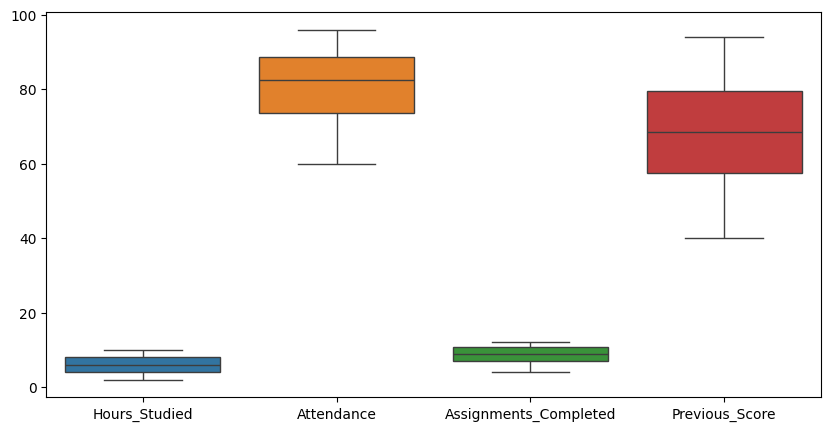

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
sns.boxplot(df)


<Axes: >

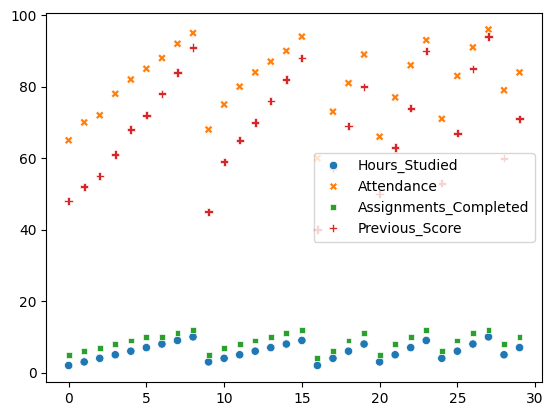

In [68]:
sns.scatterplot(df)

In [69]:
df.head()

,Hours_Studied,Attendance,Assignments_Completed,Previous_Score,Performance
0,2,65,5,48,Fail
1,3,70,6,52,Fail
2,4,72,7,55,Pass
3,5,78,8,61,Pass
4,6,82,9,68,Pass


In [70]:
x=df.drop(columns='Performance')
x.head()

,Hours_Studied,Attendance,Assignments_Completed,Previous_Score
0,2,65,5,48
1,3,70,6,52
2,4,72,7,55
3,5,78,8,61
4,6,82,9,68


In [71]:
y=df["Performance"]
y.head()

0    Fail
1    Fail
2    Pass
3    Pass
4    Pass
Name: Performance, dtype: str

In [72]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [73]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,LabelEncoder

In [74]:
preprocessor=ColumnTransformer(
    transformers=[
        (
            'minimise',
            StandardScaler(),
            ['Hours_Studied','Attendance','Assignments_Completed','Previous_Score']

        ),

    ],remainder='passthrough'
).set_output(transform='pandas')

In [75]:
X_train_transformed=preprocessor.fit_transform(X_train)

In [76]:
X_train_transformed.head()


,minimise__Hours_Studied,minimise__Attendance,minimise__Assignments_Completed,minimise__Previous_Score
28,-0.319874,-0.092186,-0.204294,-0.497258
24,-0.831672,-1.023753,-1.184908,-1.085563
12,0.191924,0.490043,0.286012,0.343178
0,-1.855268,-1.722429,-1.675215,-1.505781
4,0.191924,0.257151,0.286012,0.175091


<Axes: >

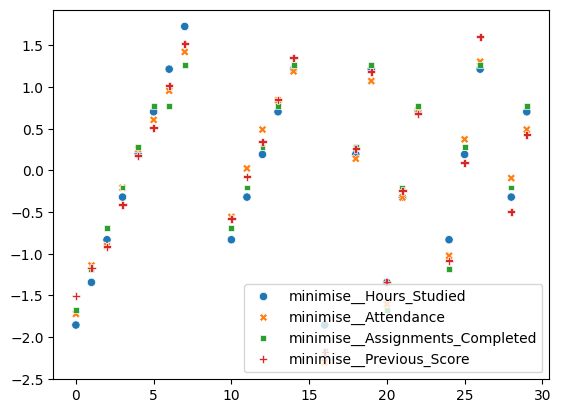

In [77]:
sns.scatterplot(X_train_transformed)

In [78]:
X_test_transformed=preprocessor.transform(X_test)

In [79]:
from sklearn.preprocessing import LabelEncoder
y

0          Fail
1          Fail
2          Pass
3          Pass
4          Pass
5          Good
6          Good
7     Excellent
8     Excellent
9          Fail
10         Pass
11         Pass
12         Good
13         Good
14    Excellent
15    Excellent
16         Fail
17         Pass
18         Good
19    Excellent
20         Fail
21         Pass
22         Good
23    Excellent
24         Fail
25         Good
26    Excellent
27    Excellent
28         Pass
29         Good
Name: Performance, dtype: str

In [80]:
encoder=LabelEncoder()

y_train=encoder.fit_transform(y_train)
y_test=encoder.transform(y_test)

In [81]:
from sklearn.linear_model import LogisticRegression

In [82]:
model=LogisticRegression()

In [83]:
model.fit(X_train_transformed,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [84]:
y_pred=model.predict(X_test_transformed)
y_pred

array([0, 0, 0, 3, 0, 1])

In [85]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_pred,y_test)
accuracy

1.0

In [87]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_pred,y_test)
cm

array([[4, 0, 0],
       [0, 1, 0],
       [0, 0, 1]])

In [93]:
from sklearn.metrics import classification_report
report=classification_report(y_test,y_pred,output_dict=True)
report_df=pd.DataFrame(report).T
report_df

,precision,recall,f1-score,support
0,1.0,1.0,1.0,4.0
1,1.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,6.0
weighted avg,1.0,1.0,1.0,6.0
